# Ray-set viewer

The 21 candidate ray-sets, one at a time.

**Run all cells**, then:
- **drag** on the plot to rotate it in 3D,
- use the **dropdown** to switch between ray-sets.

Rays are drawn from the origin and coloured by family (each shape has up to three).


interactive(children=(Dropdown(description='ray-set:', options=(('T · 4a   (4 rays)', 0), ('T · 4b   (4 rays)'…

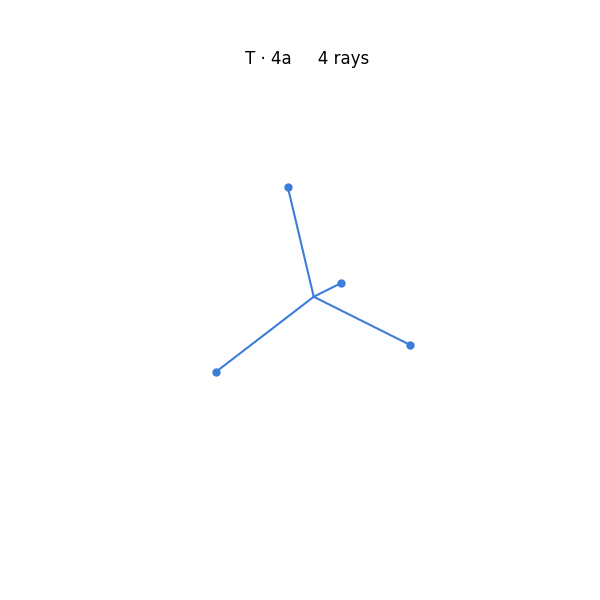

In [5]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as w
import raysets

SETS = raysets.build()
PALETTE = ["#3b7dd8", "#e8833a", "#2ca58d"]   # one colour per family

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

def draw(k=0):
    ax.clear()
    rs = SETS[k]
    for f, fam in enumerate(rs.families):
        c = PALETTE[f % len(PALETTE)]
        for v in fam:
            ax.plot([0, v[0]], [0, v[1]], [0, v[2]], color=c, lw=1.5)
        ax.scatter(fam[:, 0], fam[:, 1], fam[:, 2],
                   color=c, s=25, depthshade=False)
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1); ax.set_zlim(-1.1, 1.1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()
    ax.set_title(f"{raysets.label(rs)}     {raysets.count(rs)} rays")
    fig.canvas.draw_idle()

options = [(f"{raysets.label(rs)}   ({raysets.count(rs)} rays)", k)
           for k, rs in enumerate(SETS)]
picker = w.Dropdown(options=options, description="ray-set:")
w.interact(draw, k=picker);


## The families that don't stop

The 16 all come from the three polyhedral shapes. Two *other* kinds of symmetry
exist in 3D, and they behave very differently from each other — slide `n` and watch.

- **C — turntable.** One axis, so exactly two poles. Change `n` and **nothing
  moves**. A 5-fold turntable and a 17-fold turntable have the identical ray-set.
  Their infinitude lives in *how far* you may turn, which a ray-set forgets.
- **D — prism.** An n-fold axis (blue) plus n perpendicular 2-fold axes, whose
  poles form two interleaved rings around the equator (orange and green). Every
  step of `n` adds two more rays, forever. This is the family that is genuinely
  infinite *as geometry*.

Worth stopping at **D, n = 2**: its six rays are the three coordinate axes — which
is exactly the Rubik's Cube's ray-set `O · 6`. These families overlap the 16 rather
than sitting neatly beside them.


interactive(children=(RadioButtons(description='family:', index=1, options=('C — turntable', 'D — prism'), val…

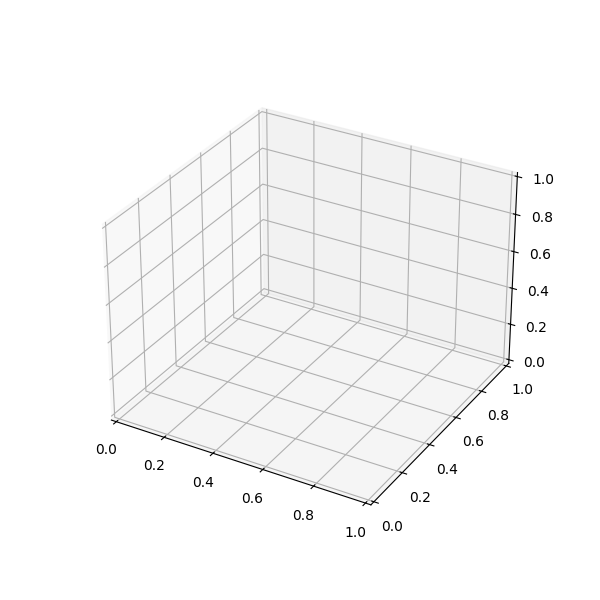

In [ ]:
fig2 = plt.figure(figsize=(6, 6))
ax2 = fig2.add_subplot(111, projection="3d")

def draw_family(kind="D — prism", n=5):
    rs = raysets.cyclic(n) if kind.startswith("C") else raysets.dihedral(n)
    ax2.clear()
    for f, fam in enumerate(rs.families):
        c = PALETTE[f % len(PALETTE)]
        for v in fam:
            ax2.plot([0, v[0]], [0, v[1]], [0, v[2]], color=c, lw=1.5)
        ax2.scatter(fam[:, 0], fam[:, 1], fam[:, 2],
                    color=c, s=25, depthshade=False)
    ax2.set_xlim(-1.1, 1.1); ax2.set_ylim(-1.1, 1.1); ax2.set_zlim(-1.1, 1.1)
    ax2.set_box_aspect((1, 1, 1))
    ax2.set_axis_off()
    ax2.set_title(f"{raysets.label(rs)}     {raysets.count(rs)} rays")
    fig2.canvas.draw_idle()

w.interact(draw_family,
           kind=w.RadioButtons(options=["C — turntable", "D — prism"],
                               value="D — prism", description="family:"),
           n=w.IntSlider(min=2, max=12, value=5, description="n:"));


---
**If the plot doesn't appear or won't rotate:** the interactive backend isn't
wired up. Two fallbacks —

- Replace `%matplotlib widget` with `%matplotlib qt` (or `%matplotlib tk`) to pop
  the plot out into its own draggable window, or
- run the standalone script from a terminal in this folder: `python rayview.py`
  (arrow keys step through the ray-sets there).
